**Academic Integrity Declaration**

Academic Integrity and Learning Statement

By submitting my work, I confirm that:

1. The code, analysis, and documentation in this notebook are my own work and reflect my own understanding.
2. I am prepared to explain all code and analysis included in this submission.

If I used assistance (e.g., AI tools, tutors, or other resources), I have:

- Clearly documented where and how external tools or resources were used in my solution.
- Included a copy of the interaction (e.g., AI conversation or tutoring notes) in an appendix.

I acknowledge that:

- I may be asked to explain any part of my code or analysis during evaluation.
- Misrepresenting assisted work as my own constitutes academic dishonesty and undermines my learning.


**A. An overview of the dataset**

In this section, I load the dataset and inspect its main characteristics before starting any further analysis.  
The goal is to understand the structure of the dataset, including its size, variables, data types, and missing values.

I will:
1. Import the dataset as a pandas DataFrame named 'df'
2. Check the number of rows and columns
3. Display the first few entries
4. Inspect the index and column names
5. Check the data type of each column
6. Identify missing values and display the rows containing them
7. Remove incomplete observations if necessary so that the dataset is ready for later analysis

**1. Import the dataset**

In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
sns.set_theme(style="whitegrid")

In [80]:
df = pd.read_csv("p1_communes.csv")
df

,Canton,Commune,Language,Residents,Population density per km²,0-19 years,20-64 years,65 years or over,Private households,Surface area in km²,Settlement area,Agricultural area,Wooded area,Unproductive area,East coordinate,North coordinate,Elevation
0,ZH,Aeugst am Albis,de,1982,250.568900,19.677094,62.764884,17.558022,835,7.91,12.658228,51.139241,30.886076,5.316456,2679300,1235700,673
1,ZH,Affoltern am Albis,de,12229,1154.768650,20.508627,61.329626,18.161747,5348,10.59,30.674264,40.170940,28.205128,0.949668,2676800,1236800,502
2,ZH,Bonstetten,de,5548,746.702557,23.666186,60.310022,16.023792,2325,7.43,15.456989,55.510753,28.629032,0.403226,2677800,1241000,583
3,ZH,Hausen am Albis,de,3701,272.132353,21.804918,60.686301,17.508781,1546,13.60,12.692590,55.906090,28.833456,2.567865,2682900,1233100,653
4,ZH,Hedingen,de,3734,571.822358,21.772898,61.756829,16.470273,1540,6.53,19.817073,46.341463,33.231707,0.609756,2676400,1239000,543
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2197,JU,Vendlincourt,fr,540,59.016393,18.888889,56.296296,24.814815,224,9.15,6.338798,55.846995,37.595628,0.218579,2578200,1255600,471
2198,JU,Basse-Allaine,fr,1230,53.385417,21.869919,52.195122,25.934959,540,23.04,7.391304,44.043478,47.652174,0.913043,2569300,1258900,456
2199,JU,Clos du Doubs,fr,1286,20.825911,18.895801,56.143079,24.961120,574,61.75,3.626356,42.884896,52.096487,1.392262,2579100,1246300,683
2200,JU,Haute-Ajoie,fr,1095,26.752993,18.264840,56.347032,25.388128,493,40.93,4.054714,56.301905,39.618955,0.024426,2567000,1249100,592


**2. Check the number of rows and columns**

In [81]:
df.shape

(2202, 17)

The dataset contains 2202 rows and 17 columns.

**3. Display the first few rows**

In [82]:
df.head()

,Canton,Commune,Language,Residents,Population density per km²,0-19 years,20-64 years,65 years or over,Private households,Surface area in km²,Settlement area,Agricultural area,Wooded area,Unproductive area,East coordinate,North coordinate,Elevation
0,ZH,Aeugst am Albis,de,1982,250.568900,19.677094,62.764884,17.558022,835,7.91,12.658228,51.139241,30.886076,5.316456,2679300,1235700,673
1,ZH,Affoltern am Albis,de,12229,1154.768650,20.508627,61.329626,18.161747,5348,10.59,30.674264,40.170940,28.205128,0.949668,2676800,1236800,502
2,ZH,Bonstetten,de,5548,746.702557,23.666186,60.310022,16.023792,2325,7.43,15.456989,55.510753,28.629032,0.403226,2677800,1241000,583
3,ZH,Hausen am Albis,de,3701,272.132353,21.804918,60.686301,17.508781,1546,13.60,12.692590,55.906090,28.833456,2.567865,2682900,1233100,653
4,ZH,Hedingen,de,3734,571.822358,21.772898,61.756829,16.470273,1540,6.53,19.817073,46.341463,33.231707,0.609756,2676400,1239000,543


**4. Index and columns**

In [83]:
df.index
df.columns.tolist()

['Canton',
 'Commune',
 'Language',
 'Residents',
 'Population density per km²',
 '0-19 years',
 '20-64 years',
 '65 years or over',
 'Private households',
 'Surface area in km²',
 'Settlement area',
 'Agricultural area',
 'Wooded area',
 'Unproductive area',
 'East coordinate',
 'North coordinate',
 'Elevation']

The dataset includes variables related to canton, commune name, language, population structure, households, land use, coordinates, and elevation.
This confirms that the dataset mixes categorical and numerical information.

**5. Data types**

In [84]:
df.dtypes

,0
Canton,object
Commune,object
Language,object
Residents,int64
Population density per km²,float64
0-19 years,float64
20-64 years,float64
65 years or over,float64
Private households,int64
Surface area in km²,float64


**6. Missing values count**

In [85]:
df.isnull().sum()

,0
Canton,3
Commune,0
Language,11
Residents,0
Population density per km²,0
0-19 years,0
20-64 years,0
65 years or over,0
Private households,0
Surface area in km²,0


**6. Show rows with missing values**

In [86]:
mv=df[df.isnull().any(axis=1)]
print(mv)

     Canton            Commune Language  Residents  \
155      ZH          Stammheim      NaN       2747   
156      ZH          Wädenswil      NaN      24341   
157      ZH               Elgg      NaN       4903   
158      ZH             Horgen      NaN      22665   
440     NaN            Thurnen      NaN       1922   
704     NaN             Villaz      NaN       2287   
757     NaN               Prez      NaN       2236   
1133     GR     Bergün Filisur      NaN        905   
1165     GR          Rheinwald      NaN        577   
1626     TI            Riviera      NaN       4220   
2079     NE  La Grande Béroche      NaN       8852   

      Population density per km²  0-19 years  20-64 years  65 years or over  \
155                   114.649416   21.405169    58.281762         20.313069   
156                   682.968575   19.740356    59.944127         20.315517   
157                   201.025010   20.762798    60.473180         18.764022   
158                   735.160558   

**7. Remove any observations to ensure that there are no missing values and the values in each column are of the same data type.**

In [87]:
df = df.dropna().copy()
df.shape

(2191, 17)

In [88]:
display(df.dtypes)

,0
Canton,object
Commune,object
Language,object
Residents,int64
Population density per km²,float64
0-19 years,float64
20-64 years,float64
65 years or over,float64
Private households,int64
Surface area in km²,float64


**Conclusion**

After cleaning, the dataset contains 2191 rows and 17 columns.  
All missing values have been removed, and the variables have consistent data types.

The dataset is now ready for the next stages of exploration and visualization.

**B. Exploration: numerical summaries, indexing and grouping**

In this section, I explore the dataset using numerical summaries and grouping techniques.

The goal is to:
- summarize numerical variables
- identify extreme observations
- group data by canton
- derive new insights such as population density and elevation range

This helps reveal patterns and differences across communes and cantons.

**1. Numerical summaries with mean, minimum and maximum value**

In [89]:
numerical_cols = df.select_dtypes(include=np.number)
display(numerical_cols.agg(['mean','min','max']))

,Residents,Population density per km²,0-19 years,20-64 years,65 years or over,Private households,Surface area in km²,Settlement area,Agricultural area,Wooded area,Unproductive area,East coordinate,North coordinate,Elevation
mean,3865.299863,433.424048,20.585167,60.371180,19.043653,1702.485167,17.97283,14.882541,45.929853,32.575829,6.611777,2.631543e+06,1.202302e+06,768.209493
min,11.000000,0.895037,0.000000,18.181818,6.271186,10.000000,0.31000,0.138897,0.000000,0.000000,0.000000,2.486700e+06,1.077200e+06,200.000000
max,415367.000000,12669.052100,37.777778,77.922078,81.818182,201252.000000,438.63000,97.260274,91.509434,88.235294,95.022860,2.828800e+06,1.294100e+06,3080.000000


**2. Top 10 most populated communes**

In [90]:
top_10_most_populated_communes = df.sort_values(by='Residents', ascending=False)
display(top_10_most_populated_communes.head(10).Commune.tolist())

['Zürich',
 'Genève',
 'Basel',
 'Lausanne',
 'Bern',
 'Winterthur',
 'Luzern',
 'St. Gallen',
 'Lugano',
 'Biel/Bienne']

This shows the 10 most populated communes, which represent the largest population centers in Switzerland and are likely to be major urban areas.

**3. Top 10 least populated communes**

In [91]:
top_10_least_populated_communes = df.sort_values(by='Residents', ascending=True)
display(top_10_least_populated_communes.head(10).Commune.tolist())

['Corippo',
 'Kammersrohr',
 'Bister',
 'Schelten',
 'Rebévelier',
 'Berken',
 'Cerentino',
 'Clavaleyres',
 'Lohn (GR)',
 'Bosco/Gurin']

This shows the 10 least populated communes, which are typically small rural or mountainous areas with very low population.

**4. Group by canton and save as CSV**

In [92]:
for Canton, group in df.groupby('Canton'):
     group.to_csv(f"{Canton}.csv", index=False)

**5. Population density by canton**

In [93]:
canton_summary = df.groupby('Canton').agg(total_residents=('Residents','sum'),total_surface_area=('Surface area in km²', 'sum')).reset_index()

In [94]:
canton_summary['Canton_Population_Density'] = canton_summary['total_residents'] / canton_summary['total_surface_area']

In [95]:
canton_summary = canton_summary.sort_values(by='Canton_Population_Density', ascending=False)
display(canton_summary[['Canton', 'Canton_Population_Density']].reset_index(drop=True))

,Canton,Canton_Population_Density
0,BS,5271.069012
1,GE,2031.893255
2,ZH,948.443099
3,ZG,612.265881
4,BL,556.593969
5,AG,486.145498
6,SO,345.618319
7,TG,320.320701
8,LU,286.577848
9,VD,283.275259


**Observations**

The table above shows all cantons ranked by population density. It is clear that cantons like **Basel-Stadt (BS), Geneva (GE)** have significantly higher population densities compared to others. These are major urban centers in Switzerland, characterized by smaller land areas and high resident populations.

Conversely, cantons with lower population densities appeared at the bottom of the ranked list, despite having the larger surface areas. This observations show that Switzerland population is highly concentrated around its main cities.

**6. Communes with >50% aged 20–64**

In [96]:
commune_20_64_per_canton = df[df['20-64 years'] > 50].groupby('Canton').size().reset_index(name='Number of Communes')
display(commune_20_64_per_canton)

,Canton,Number of Communes
0,AG,210
1,AI,6
2,AR,20
3,BE,339
4,BL,86
5,BS,3
6,FR,131
7,GE,45
8,GL,3
9,GR,100


**7. Elevation range**

In [97]:
elevation_range_per_canton = df.groupby('Canton')['Elevation'].agg(['min','max']).reset_index()
elevation_range_per_canton['Elevation_Range'] = elevation_range_per_canton['max'] - elevation_range_per_canton['min']

display(elevation_range_per_canton[['Canton', 'Elevation_Range']])

,Canton,Elevation_Range
0,AG,408
1,AI,432
2,AR,488
3,BE,2025
4,BL,599
5,BS,184
6,FR,988
7,GE,116
8,GL,587
9,GR,2017


In [98]:
elevation_range_per_canton = elevation_range_per_canton.sort_values("Elevation_Range", ascending=False).head(5).reset_index()
display(elevation_range_per_canton[['Canton', 'Elevation_Range']])

,Canton,Elevation_Range
0,VS,2610
1,TI,2044
2,BE,2025
3,GR,2017
4,UR,1871


**C. Exploration: visualizations**

In this section, I use visualizations to explore the dataset and uncover patterns in population, land use, age distribution, and geography.

Visualizations help better understand relationships between variables and support data-driven insights.

**C1. Horizontal bar chart**

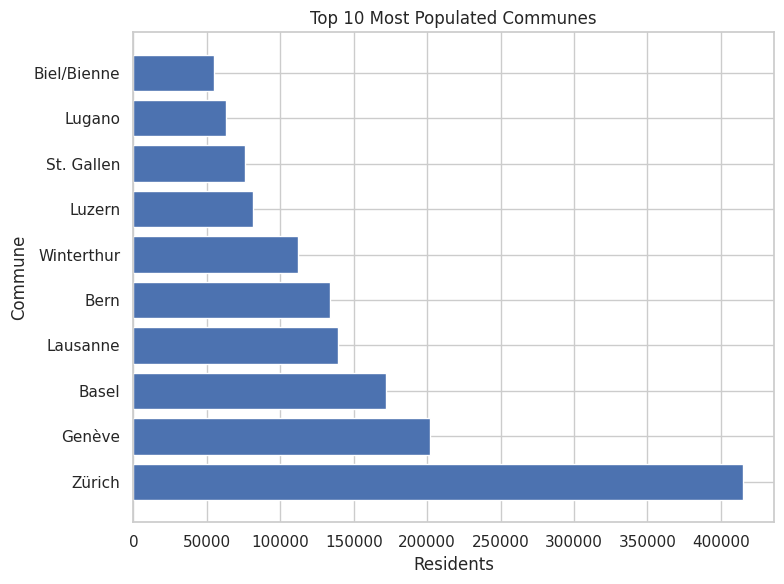

In [99]:
top_10_populated_plot = df.sort_values("Residents", ascending=False).head(10)

plt.figure(figsize=(8, 6))
plt.barh(top_10_populated_plot['Commune'], top_10_populated_plot['Residents'])
plt.xlabel("Residents")
plt.ylabel("Commune")
plt.title("Top 10 Most Populated Communes")
plt.tight_layout()
plt.show()

The bar chart shows the 10 most populated communes, in which Zurich has significantly higher populations compared to others.

**2. Horizontal stacked bar chart**

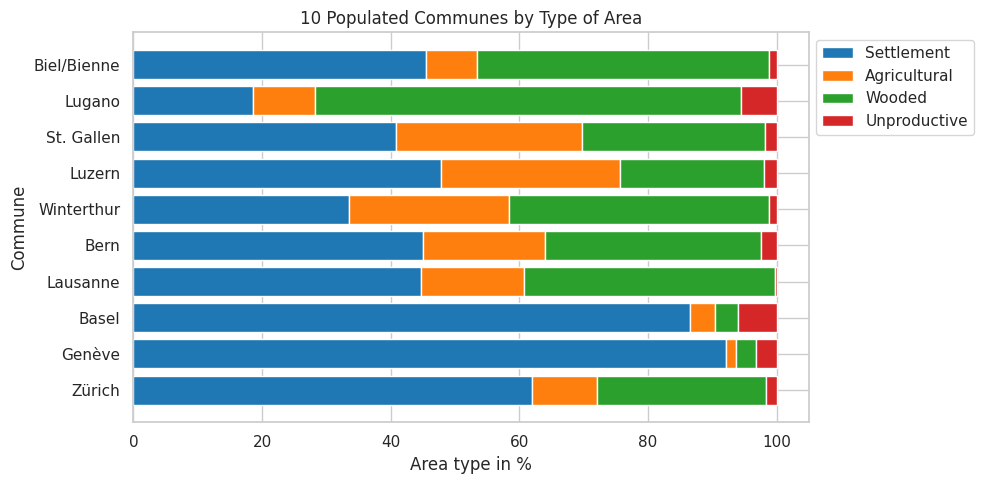

In [100]:
lands = top_10_populated_plot.copy()
plt.figure(figsize=(10, 5))
y_pos = lands["Commune"]

plt.barh(y_pos, lands["Settlement area"], color="tab:blue", label="Settlement")
plt.barh(y_pos,lands["Agricultural area"], color="tab:orange", left=lands["Settlement area"], label="Agricultural")
plt.barh(y_pos, lands["Wooded area"], color="tab:green", left=lands["Settlement area"] + lands["Agricultural area"], label="Wooded")
plt.barh(y_pos, lands["Unproductive area"], color="tab:red", left= lands["Settlement area"] + lands["Agricultural area"] +lands["Wooded area"], label="Unproductive")

plt.xlabel("Area type in %")
plt.ylabel("Commune")
plt.title("10 Populated Communes by Type of Area")
plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
plt.xlim(0, 105)
plt.tight_layout()
plt.show()

Most highly populated communes have a larger proportion of Settlement areas, reflecting urbanization.

Agricultural and wooded areas are still present but less dominant.

Unproductive areas are generally small, indicating that densely populated regions are typically more developed and usable.

**3. Histogram**

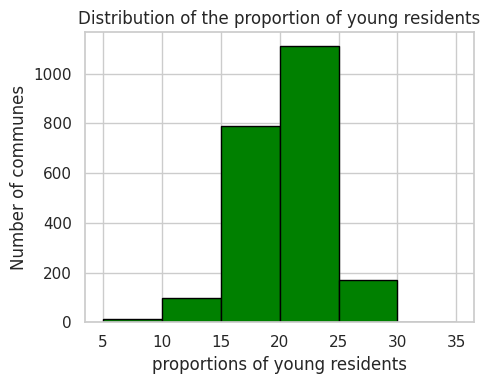

In [101]:
bins = [5, 10, 15, 20, 25, 30, 35]
labels = ['5%-10%', '10%-15%', '15%-20%', '20%-25%', '25%-30%', '30%-35%']

plt.figure(figsize=(5, 4))
plt.hist(df['0-19 years'], bins=bins, color='green', edgecolor='black')
plt.xlabel("proportions of young residents")
plt.ylabel("Number of communes")
plt.title("Distribution of the proportion of young residents")
plt.tight_layout()
plt.show()


The histogram shows how communes are distributed based on the proportion of young residents.

Most communes fall within the middle ranges (15-25), indicating a relatively balanced demographic structure.

**4. Age and Language**

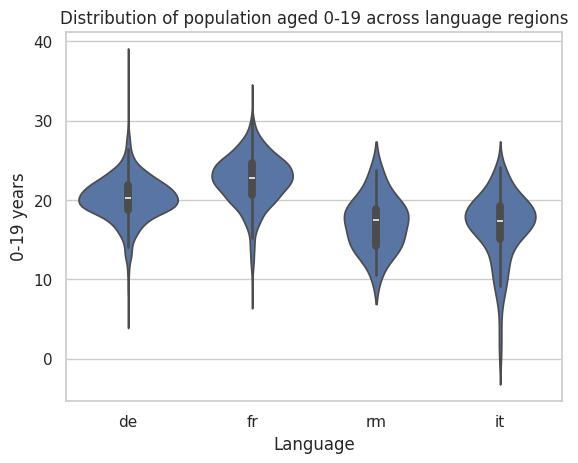

In [102]:
sns.violinplot(x=df.Language, y=df['0-19 years'])
plt.title("Distribution of population aged 0-19 across language regions")

plt.show()

Overall, the youth demographic (0–19 years) is quite consistent across Switzerland's language regions. However, the French-speaking region demonstrates a more synchronized younger profile (higher median), while the German-speaking region exhibits the highest level of internal disparity, containing several outliers that significantly exceed the national average for this age group.

**5. Subplots**

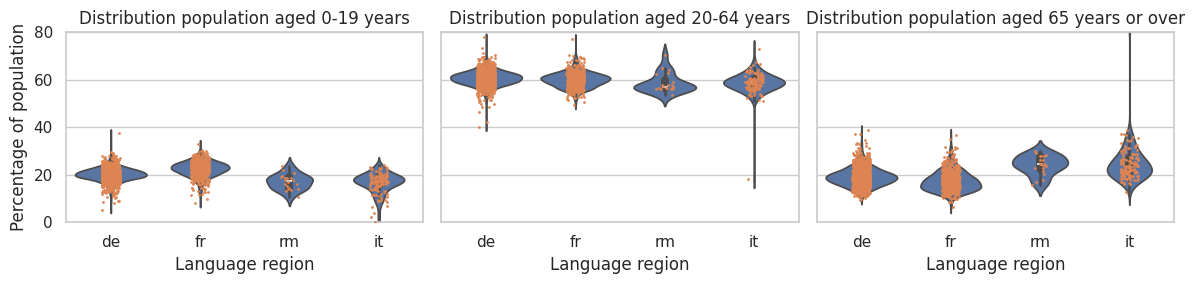

In [103]:
fig, axes = plt.subplots(nrows = 1, ncols = 3, figsize = (12, 3), sharey=True)
age_groups = ["0-19 years", "20-64 years", "65 years or over"]

sns.violinplot(x=df["Language"], y=df["0-19 years"], ax=axes[0])
sns.stripplot(x=df["Language"], y=df["0-19 years"], ax=axes[0], size=2)
axes[0].set_title("Distribution population aged 0-19 years")
axes[0].set_xlabel("Language region")
axes[0].set_ylabel("Percentage of population")
axes[0].set_ylim(0, 80)

sns.violinplot(x=df["Language"], y=df["20-64 years"], ax=axes[1])
sns.stripplot(x=df["Language"], y=df["20-64 years"], ax=axes[1], size=2)
axes[1].set_title("Distribution population aged 20-64 years")
axes[1].set_xlabel("Language region")
axes[1].set_ylabel("Percentage of population")
axes[1].set_ylim(0, 80)

sns.violinplot(x=df["Language"], y=df["65 years or over"], ax=axes[2])
sns.stripplot(x=df["Language"], y=df["65 years or over"], ax=axes[2], size=2)
axes[2].set_title("Distribution population aged 65 years or over")
axes[2].set_xlabel("Language region")
axes[2].set_ylabel("Percentage of population")
axes[2].set_ylim(0, 80)

plt.tight_layout()
plt.show()

The working-age population (20–64) dominates across all regions.

The elderly population varies more significantly across language groups.

Young population (0-19) distribution is relatively consistent but still shows regional variation.

**6. Pairplot**

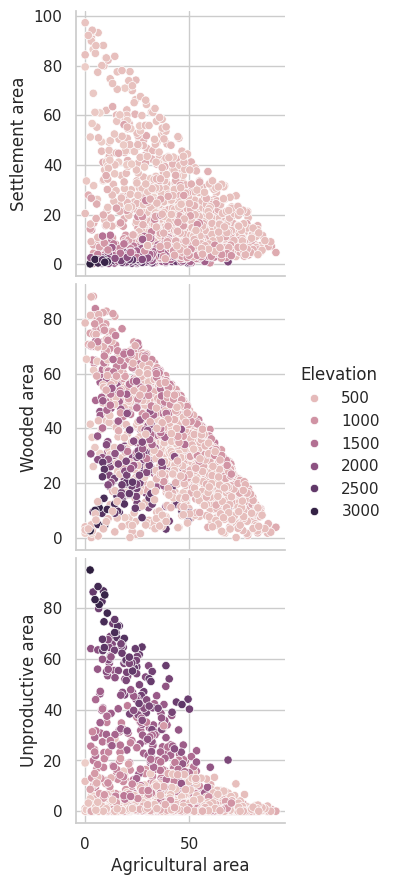

In [104]:
sns.pairplot(df,
     x_vars=["Agricultural area"],
    y_vars=["Settlement area", "Wooded area", "Unproductive area"],
    hue="Elevation",
    height=3)

plt.show()

The relationships between land types appear to be roughly linear. Also, communes at higher elevations tend to have:
- lower settlement and agricultural areas
- higher unproductive areas instead

This reflects the impact of geography on land use.

**7. Map**

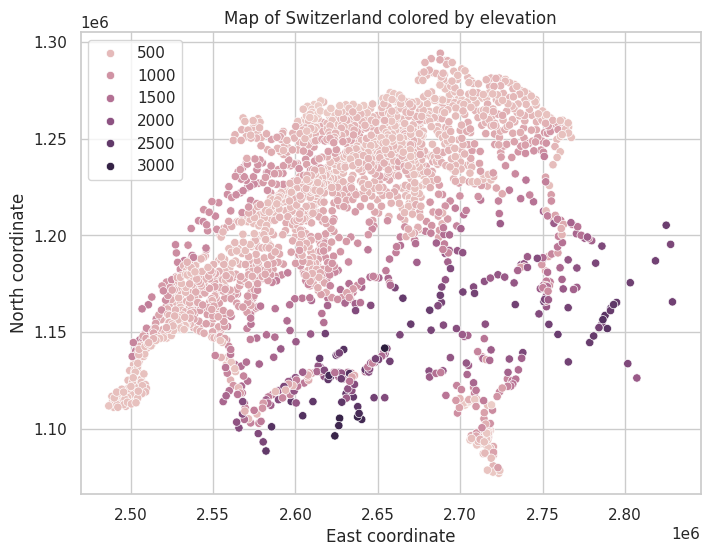

In [105]:
fig, axes = plt.subplots(nrows = 1, ncols = 1, figsize = (8, 6), sharey=True)
sns.scatterplot(data=df, x="East coordinate", y="North coordinate", hue="Elevation")
plt.title("Map of Switzerland colored by elevation")
plt.xlabel("East coordinate")
plt.ylabel("North coordinate")
plt.legend(loc="upper left")
plt.show()

The scatter plot forms the overall geographic shape of Switzerland using the East and North coordinates of the communes:
- High-elevation communes are concentrated mainly in the Alps, which occupies a large part of the south and south-east of Switzerland.
- Communes with lower elevation are more concentrated in the Central Plateau, which lies between the Alps and the Jura and corresponds to the more densely inhabited central part of the country.
- A third region is the Jura, where communes tend to have medium elevations and are located mainly in the north-west.

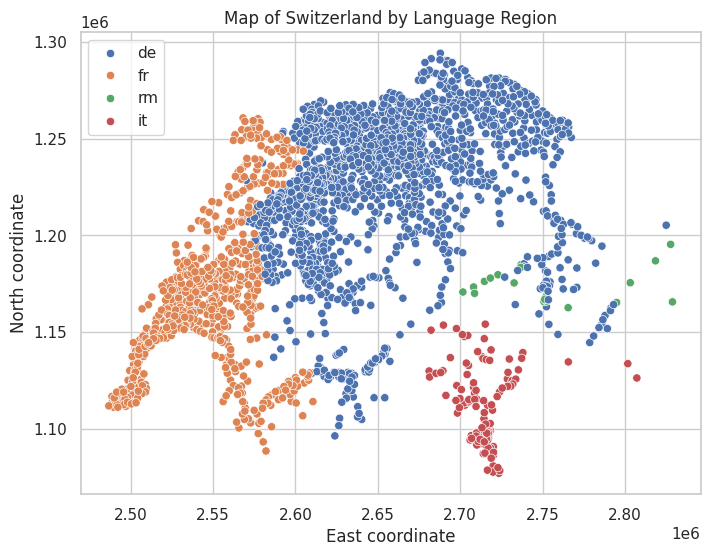

In [106]:
fig, axes = plt.subplots(nrows = 1, ncols = 1, figsize = (8, 6), sharey=True)
sns.scatterplot(data=df, x="East coordinate", y="North coordinate", hue="Language")
plt.title("Map of Switzerland by Language Region")
plt.xlabel("East coordinate")
plt.ylabel("North coordinate")
plt.legend(loc="upper left")
plt.show()

This map shows how language regions are distributed geographically:
- German-speaking communes occupy most of the central and eastern parts of Switzerland.
- French-speaking communes are concentrated in the western part of the country.
- Italian-speaking communes are located mainly in the south, separated from much of the rest of Switzerland by the Alpine region.
- Romansh-speaking communes appear little and more localized area in the south-east.

By comparing the two plots side by side, we can better understand how geography and language are related.

Overall, the language plot shows that language regions in Switzerland are strongly linked to geography and are spatially well organized rather than randomly distributed.

**8. Subplots**

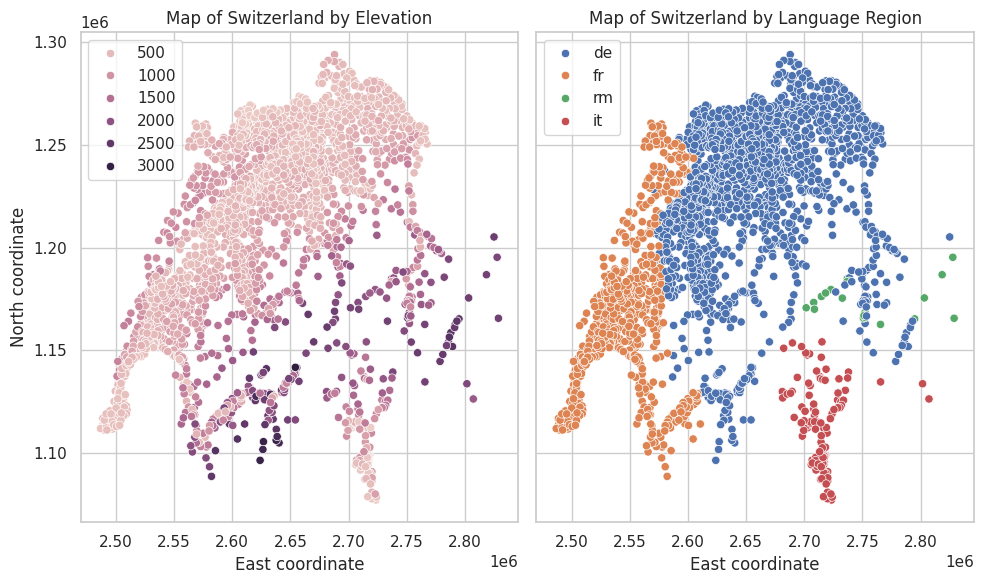

In [107]:
fig, axes = plt.subplots(nrows = 1, ncols = 2, figsize = (10, 6), sharey=True)

sns.scatterplot(data=df, x="East coordinate", y="North coordinate", hue="Elevation", ax=axes[0])
axes[0].set_title("Map of Switzerland by Elevation")
axes[0].set_xlabel("East coordinate")
axes[0].set_ylabel("North coordinate")
axes[0].legend(loc="upper left")

sns.scatterplot(data=df, x="East coordinate", y="North coordinate", hue="Language", ax=axes[1])
axes[1].set_title("Map of Switzerland by Language Region")
axes[1].set_xlabel("East coordinate")
axes[1].set_ylabel("North coordinate")
axes[1].legend(loc="upper left")

plt.tight_layout()
plt.show()

**D. Probabilities**

In [108]:
high_altitude_communes_filtered = df[df['Elevation'] > 2000]

total_high_altitude = len(high_altitude_communes_filtered)
valais_high_altitude = len(high_altitude_communes_filtered[high_altitude_communes_filtered['Canton'] == 'VS'])

if total_high_altitude > 0:
    probability_valais_given_high_altitude = valais_high_altitude / total_high_altitude
else:
    probability_valais_given_high_altitude = 0
print(f'p = {probability_valais_given_high_altitude}')

p = 0.5104166666666666


From the result, I observe that a large proportion of high-elevation communes belong to Valais.

**E. Matrices**

In [109]:
out = pd.crosstab(df["Commune"], df["Canton"])

This type of matrix representation is useful because it converts categorical data into numerical form, which is an important step when preparing data for machine learning models.

**Appendix**


**A6-A7**

To better understand how to handle missing values in pandas, I referred to external resources: https://towardsdatascience.com/handling-missing-values-with-pandas-b876bf6f008f/

This helped me understand common approaches such as:
- detecting missing values using 'isnull()'
- removing rows with 'dropna()'
- optionally filling values using 'fillna()'

I used **dropna()** in my dataset since the number of missing values was small.

**B4**

To implement grouping and saving each canton into separate CSV files, I referred to external guidance: https://stackoverflow.com/questions/46556220/save-grouped-by-results-into-separate-csv-files

Key idea learned:
- Use 'groupby()' to split data by canton
- Iterate through groups using a loop
- Save each group using 'to_csv()'

I adapted this approach to match the dataset structure and ensure correct file naming.


**B5**

To better understand how to compute population density at the canton level, I discussed the approach with an AI assistant (Gemini).

Prompt:
How can I compute population density at the canton level using pandas?

Response in summary:
- Group the dataset by canton using 'groupby()'
- Aggregate population and surface area using 'sum()'
- Compute population density as: population / surface area
- Sort the results to rank cantons by density

My understanding and implementation:
1. Group communes by canton
2. Sum the total number of residents and total surface area
3. Compute population density
4. Rank cantons from most dense to least dense

The implementation was adapted to fit the structure of the dataset used in this project.

**C1**

To understand more clearly about the horizontal bar chart, I referred to the matplotlib documentation: https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.barh.html

Key concepts learned:
- Use 'plt.barh()' to create horizontal bar charts

Based on this, I created a horizontal bar chart to display the top 10 most populated communes.

The implementation was adapted to:
- sort the dataset by population
- select the top 10 communes
- properly label axes and title for clarity

**C3**

To better understand how to group numerical data into intervals for visualization, I referred to a Kaggle discussion:

- https://www.kaggle.com/discussions/questions-and-answers/529789

From this discussion, I learned that:
- numerical data can be divided into intervals (bins) using tools like 'pd.cut()' or directly through the 'bins' parameter in plotting functions
- each bin represents a range (e.g., 5%–10%, 10%–15%)

My understanding and implementation:
Based on this, I used predefined interval boundaries (5% to 35%) in the histogram to group communes according to the proportion of young residents.

Instead of manually categorizing the data, I used the 'bins' parameter in 'plt.hist()' to:
- ensure consistent interval ranges
- visualize how communes are distributed across these categories

This approach provides a clear overview of demographic distribution across communes.

**E**

To understand how to replace or fill values in a pandas DataFrame, I referred to the following StackOverflow discussion: https://stackoverflow.com/questions/72606869python-pandas-dataframe-fill-dataframe-with-0-1

From this resource, I learned:
- how to use pd.crosstab

Based on this reference, I applied appropriate methods to ensure that the dataset values were correctly formatted and consistent for analysis.


**Overall**

The final visualization clearly shows how land is distributed across different commune types.
Some parts of this notebook were developed with the assistance of AI tools. These tools were mainly used to clarify conceptual topics (e.g., conditional probability and data visualization) and to provide guidance on implementing solutions in Python using libraries such as pandas, matplotlib, and seaborn.

In addition, publicly available online documentation was consulted to support the coding process.

All code, analyses, and interpretations were carefully reviewed, adapted, and completed independently by myself.